# Financial Sentiment Analysis (Naive Bayes)
## Phase 1: Data Loading & Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load the dataset
df = pd.read_csv('data/raw/data.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (5842, 2)
Columns: ['Sentence', 'Sentiment']


In [3]:
# Explore data
print("Sentiment distribution:")
print(df['Sentiment'].value_counts())
print(f"\nClass balance: {df['Sentiment'].value_counts(normalize=True).round(3).to_dict()}")

Sentiment distribution:
Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64

Class balance: {'neutral': 0.536, 'positive': 0.317, 'negative': 0.147}


In [4]:
# Preview sample texts for each sentiment
print("Sample positive sentiment:")
print(df[df['Sentiment'] == 'positive']['Sentence'].iloc[0][:200], "...\n")

print("Sample negative sentiment:")
print(df[df['Sentiment'] == 'negative']['Sentence'].iloc[0][:200], "...\n")

print("Sample neutral sentiment:")
print(df[df['Sentiment'] == 'neutral']['Sentence'].iloc[0][:200], "...")

Sample positive sentiment:
The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant multimedia content and a new and powerful  ...

Sample negative sentiment:
$ESI on lows, down $1.50 to $2.50 BK a real possibility ...

Sample neutral sentiment:
According to the Finnish-Russian Chamber of Commerce , all the major construction companies of Finland are operating in Russia . ...


Retaining stopwords and punctuation is essential for financial text as symbols like $, %, and special patterns reveal sentiment.

In [5]:
# Preprocessing: Lowercase only - keep all punctuation
def preprocess_text(text):
    if pd.isna(text):
        return ""
    return str(text).lower()

df['processed_text'] = df['Sentence'].apply(preprocess_text)

# Convert labels to numeric: positive=2, neutral=1, negative=0
sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['Sentiment'].map(sentiment_map)

print("Preprocessing complete!")
print(f"Label mapping: {sentiment_map}")
print(f"Label distribution: {df['label'].value_counts().to_dict()}")

Preprocessing complete!
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
Label distribution: {1: 3130, 2: 1852, 0: 860}


## Visualization: Class Distribution

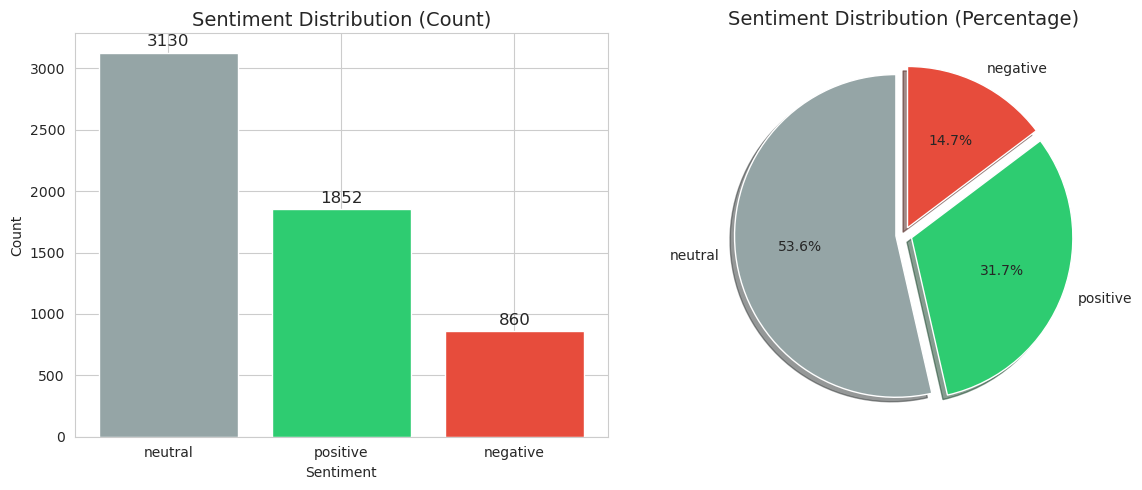

In [6]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sentiment_counts = df['Sentiment'].value_counts()
colors = ['#95a5a6', '#2ecc71', '#e74c3c']

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[0].set_title('Sentiment Distribution (Count)', fontsize=14)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=12)

axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
        colors=colors, explode=(0.05, 0.05, 0.05), shadow=True, startangle=90)
axes[1].set_title('Sentiment Distribution (Percentage)', fontsize=14)

plt.tight_layout()
plt.show()

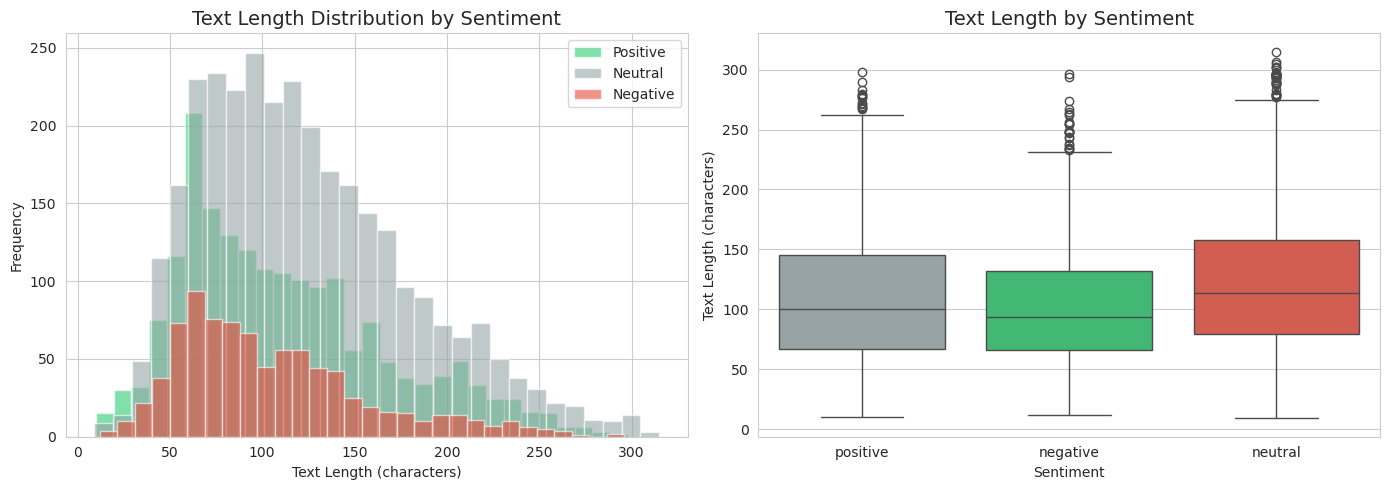


Text Length Stats:
            count        mean        std   min   25%    50%     75%    max
Sentiment                                                                 
negative    860.0  105.330233  51.798956  12.0  66.0   94.0  132.25  296.0
neutral    3130.0  123.113419  56.872104   9.0  79.0  114.0  158.00  315.0
positive   1852.0  112.157127  56.412443  10.0  67.0  100.0  145.25  298.0


In [7]:
# Visualize text length distribution
df['text_length'] = df['Sentence'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sentiment, color, label in [('positive', '#2ecc71', 'Positive'), 
                                  ('neutral', '#95a5a6', 'Neutral'),
                                  ('negative', '#e74c3c', 'Negative')]:
    axes[0].hist(df[df['Sentiment'] == sentiment]['text_length'], bins=30, alpha=0.6, 
                 label=label, color=color)

axes[0].set_title('Text Length Distribution by Sentiment', fontsize=14)
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.boxplot(x='Sentiment', y='text_length', data=df, ax=axes[1], 
            hue='Sentiment', palette=colors, legend=False)
axes[1].set_title('Text Length by Sentiment', fontsize=14)
axes[1].set_ylabel('Text Length (characters)')

plt.tight_layout()
plt.show()

print(f"\nText Length Stats:")
print(df.groupby('Sentiment')['text_length'].describe())

In [8]:
# Train/Test Split (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTraining labels: {y_train.value_counts().sort_index().to_dict()}")
print(f"Test labels: {y_test.value_counts().sort_index().to_dict()}")

Training set: 4673 samples
Test set: 1169 samples

Training labels: {0: 688, 1: 2504, 2: 1481}
Test labels: {0: 172, 1: 626, 2: 371}


## Phase 1 Complete! Ready for Phase 2.

## Phase 2: Bag of Words

In [9]:
from collections import Counter

# Generate N-grams from text
def generate_ngrams(text, n):
    words = text.split()
    ngrams = []
    for i in range(len(words) - n + 1):
        ngram = ' '.join(words[i:i+n])
        ngrams.append(ngram)
    return ngrams

# Build Vocabulary with N-grams support
def build_vocabulary(texts, n=1):
    vocab = set()
    for text in texts:
        ngrams = generate_ngrams(text, n)
        vocab.update(ngrams)
    return {ng: i for i, ng in enumerate(sorted(vocab))}

# Build vocabulary with unigrams
vocab = build_vocabulary(X_train, n=1)
print(f"Vocabulary size (unigrams): {len(vocab)}")

Vocabulary size (unigrams): 12352


In [10]:
# Bag of Words Vectorizer
# Converts text to vectors of word counts

class BagOfWordsVectorizer:
    """
    Bag of Words: Simple count of each word/n-gram in the text.
    Unlike TF-IDF, we just count occurrences - no weighting.
    Supports N-grams: unigrams (n=1), bigrams (n=2), trigrams (n=3)
    """
    
    def __init__(self, vocabulary, n=1):
        self.vocabulary_ = vocabulary
        self.n = n
    
    def transform(self, texts):
        vectors = []
        for text in texts:
            ngrams = generate_ngrams(text, self.n)
            ngram_counts = Counter(ngrams)
            
            # Create vector with n-gram counts
            vector = np.zeros(len(self.vocabulary_))
            for ng, count in ngram_counts.items():
                if ng in self.vocabulary_:
                    vector[self.vocabulary_[ng]] = count
            
            vectors.append(vector)
        
        return np.array(vectors)
    
    def fit_transform(self, texts, n=1):
        self.n = n
        self.vocabulary_ = build_vocabulary(texts, n)
        return self.transform(texts)

In [11]:
# Transform training and test data
bow_vectorizer = BagOfWordsVectorizer(vocab)
X_train_bow = bow_vectorizer.transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print(f"Training BoW shape: {X_train_bow.shape}")
print(f"Test BoW shape: {X_test_bow.shape}")
print(f"\nSample vector (first 10 counts): {X_train_bow[0][:10]}")

Training BoW shape: (4673, 12352)
Test BoW shape: (1169, 12352)

Sample vector (first 10 counts): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


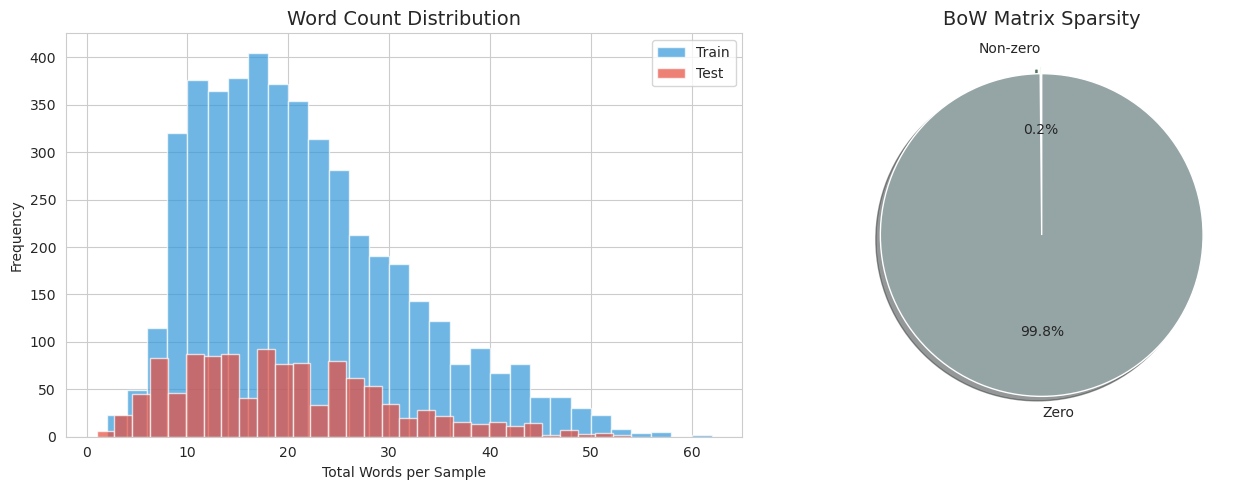


BoW Matrix Info:
  Shape: (4673, 12352)
  Sparsity: 99.8% zeros
  Average words per sample: 20.9


In [12]:
# Visualize Bag of Words distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total word counts per sample
train_totals = X_train_bow.sum(axis=1)
test_totals = X_test_bow.sum(axis=1)

axes[0].hist(train_totals, bins=30, alpha=0.7, label='Train', color='#3498db')
axes[0].hist(test_totals, bins=30, alpha=0.7, label='Test', color='#e74c3c')
axes[0].set_title('Word Count Distribution', fontsize=14)
axes[0].set_xlabel('Total Words per Sample')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Sparsity (most entries are zero)
sparsity = (X_train_bow == 0).sum() / X_train_bow.size * 100
density = 100 - sparsity

axes[1].pie([density, sparsity], labels=['Non-zero', 'Zero'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#95a5a6'],
        explode=(0.05, 0), shadow=True, startangle=90)
axes[1].set_title('BoW Matrix Sparsity', fontsize=14)

plt.tight_layout()
plt.show()

print(f"\nBoW Matrix Info:")
print(f"  Shape: {X_train_bow.shape}")
print(f"  Sparsity: {sparsity:.1f}% zeros")
print(f"  Average words per sample: {train_totals.mean():.1f}")

## Phase 2 Complete! Ready for Phase 3.

## Phase 3: Naive Bayes

In [13]:
# Naive Bayes Classifier

class NaiveBayes:
    """
    Naive Bayes for text classification
    
    Bayes' Rule: P(Class|Text) ∝ P(Text|Class) × P(Class)
    
    We use log probabilities to avoid underflow.
    Laplacian smoothing (alpha) handles unseen words.
    """
    
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # smoothing parameter
        self.class_probs = {}
        self.word_probs = {}
        self.classes = None
    
    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples, n_features = X.shape
        
        # Calculate P(Class) - prior probability
        for c in self.classes:
            self.class_probs[c] = np.sum(y == c) / len(y)
    
        # Calculate P(Word|Class) with Laplacian smoothing
        # P(word|class) = (count + alpha) / (total_words + alpha × vocab_size)
        self.word_probs = {}
        
        for c in self.classes:
            X_c = X[y == c]
            word_counts = X_c.sum(axis=0)  # total count of each word in class c
            total_words = word_counts.sum()
            
            probs = (word_counts + self.alpha) / (total_words + self.alpha * n_features)
            self.word_probs[c] = probs
    
    def predict_proba(self, X):
        probs = np.zeros((len(X), len(self.classes)))
        
        for i, x in enumerate(X):
            for c in self.classes:
                # log P(Text|Class) + log P(Class)
                log_prob = np.log(self.class_probs[c])
                
                # Add log probability for each word in the text
                nonzero = x > 0
                if nonzero.any():
                    log_prob += np.sum(x[nonzero] * np.log(self.word_probs[c][nonzero]))
                
                probs[i, c] = log_prob
        
        return probs
    
    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]

# Test different N-grams (1=unigram, 2=bigram, 3=trigram)
results = {}

print("Testing N-grams 1, 2, 3...")
print("="*50)

for n in [1, 2, 3]:
    print(f"\n{n}-gram:")
    
    # Build vocabulary and transform data
    vocab_n = build_vocabulary(X_train, n=n)
    bow_n = BagOfWordsVectorizer(vocab_n, n=n)
    X_train_n = bow_n.transform(X_train)
    X_test_n = bow_n.transform(X_test)
    
    print(f"  Vocabulary size: {len(vocab_n)}")
    
    # Train Naive Bayes
    model = NaiveBayes(alpha=1.0)
    model.fit(X_train_n, y_train)
    
    # Evaluate
    y_pred = model.predict(X_test_n)
    accuracy = np.mean(y_pred == y_test)
    
    # F1 per class
    def f1_per_class(y_true, y_pred, classes):
        results = {}
        label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
        for c in classes:
            tp = np.sum((y_pred == c) & (y_true == c))
            fp = np.sum((y_pred == c) & (y_true != c))
            fn = np.sum((y_pred != c) & (y_true == c))
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            results[label_map[c]] = {'f1': f1, 'precision': precision, 'recall': recall}
        return results

    f1_results = f1_per_class(y_test, y_pred, model.classes)
    
    # Store results
    results[n] = {
        'accuracy': accuracy,
        'f1': f1_results,
        'vocab_size': len(vocab_n)
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1 Scores: Neg={f1_results['negative']['f1']:.4f}, Neu={f1_results['neutral']['f1']:.4f}, Pos={f1_results['positive']['f1']:.4f}")

# Find best N-gram
best_n = max(results, key=lambda x: results[x]['accuracy'])
print("="*50)
print(f"BEST N-GRAM: {best_n}-gram")
print(f"  Accuracy: {results[best_n]['accuracy']:.4f}")

Testing N-grams 1, 2, 3...

1-gram:
  Vocabulary size: 12352
  Accuracy: 0.6989
  F1 Scores: Neg=0.2941, Neu=0.7870, Pos=0.6814

2-gram:
  Vocabulary size: 47899
  Accuracy: 0.6424
  F1 Scores: Neg=0.1649, Neu=0.7222, Pos=0.6850

3-gram:
  Vocabulary size: 65981
  Accuracy: 0.5595
  F1 Scores: Neg=0.1115, Neu=0.6649, Pos=0.5072
BEST N-GRAM: 1-gram
  Accuracy: 0.6989


In [14]:
# Best N-gram result from the N-gram comparison loop
print("Best N-gram results from Phase 3:")
print(f"  N-gram: {best_n}")
print(f"  Accuracy: {results[best_n]['accuracy']:.4f}")
print(f"  F1 Scores: Neg={results[best_n]['f1']['negative']['f1']:.4f}, Neu={results[best_n]['f1']['neutral']['f1']:.4f}, Pos={results[best_n]['f1']['positive']['f1']:.4f}")

# Save best results for later cells
best_f1_results = results[best_n]['f1']

# Rebuild best model for visualization
vocab_best = build_vocabulary(X_train, n=best_n)
bow_best = BagOfWordsVectorizer(vocab_best, n=best_n)
X_train_best = bow_best.transform(X_train)
X_test_best = bow_best.transform(X_test)
best_model = NaiveBayes(alpha=1.0)
best_model.fit(X_train_best, y_train)
y_pred = best_model.predict(X_test_best)

Best N-gram results from Phase 3:
  N-gram: 1
  Accuracy: 0.6989
  F1 Scores: Neg=0.2941, Neu=0.7870, Pos=0.6814


In [15]:
# F1 Score per class

def f1_per_class(y_true, y_pred, classes):
    results = {}
    label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    
    for c in classes:
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        results[label_map[c]] = {'f1': f1, 'precision': precision, 'recall': recall}
    
    return results

# Calculate F1 per class
classes = np.unique(y_train)
f1_results = f1_per_class(y_test, y_pred, classes)

print("\nResults per Class:")
print("="*50)
for class_name, metrics in f1_results.items():
    print(f"{class_name.capitalize()}:")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall: {metrics['recall']:.4f}")
    print(f"  F1 Score: {metrics['f1']:.4f}")
    print()


Results per Class:
Negative:
  Precision: 0.4000
  Recall: 0.2326
  F1 Score: 0.2941

Neutral:
  Precision: 0.7181
  Recall: 0.8706
  F1 Score: 0.7870

Positive:
  Precision: 0.7484
  Recall: 0.6253
  F1 Score: 0.6814



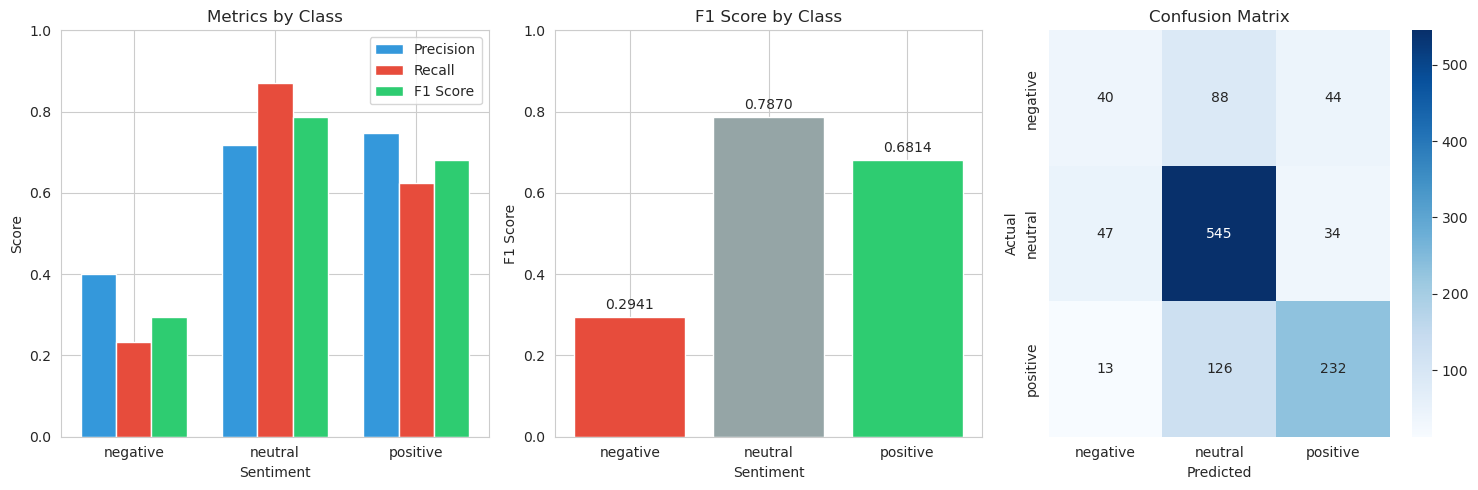

In [16]:
# Visualize results per class
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

class_names = ['negative', 'neutral', 'positive']
colors = ['#e74c3c', '#95a5a6', '#2ecc71']

precision_vals = [f1_results[c]['precision'] for c in class_names]
recall_vals = [f1_results[c]['recall'] for c in class_names]
f1_vals = [f1_results[c]['f1'] for c in class_names]

x = np.arange(len(class_names))
width = 0.25

# Bar chart comparing metrics
axes[0].bar(x - width, precision_vals, width, label='Precision', color='#3498db')
axes[0].bar(x, recall_vals, width, label='Recall', color='#e74c3c')
axes[0].bar(x + width, f1_vals, width, label='F1 Score', color='#2ecc71')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics by Class')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names)
axes[0].legend()
axes[0].set_ylim(0, 1)

# F1 bar chart
axes[1].bar(class_names, f1_vals, color=colors)
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score by Class')
axes[1].set_ylim(0, 1)
for i, v in enumerate(f1_vals):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center')

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=class_names, yticklabels=class_names)
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

## Phase 3b: Testing Negative Class Duplication

In [17]:
# Test different duplication levels for negative class

# Get indices of negative samples in training data (label 0 = negative)
neg_indices = np.where(y_train == 0)[0]
print(f"Original negative training samples: {len(neg_indices)}")

# Test multipliers: 1 (baseline), 2, 3, 3.5
multipliers = [1, 2, 3, 3.5]
dup_results = {}

for mult in multipliers:
    # Create augmented training data
    X_train_aug = list(X_train)
    y_train_aug = list(y_train)
    
    # Duplicate negative samples
    neg_samples = X_train.iloc[neg_indices].values
    neg_labels = y_train.iloc[neg_indices].values
    
    for _ in range(int(mult) - 1):
        X_train_aug.extend(neg_samples)
        y_train_aug.extend(neg_labels)
    
    # Add partial duplicate for 3.5
    if mult == 3.5:
        partial = len(neg_samples) // 2
        X_train_aug.extend(neg_samples[:partial])
        y_train_aug.extend(neg_labels[:partial])
    
    # Convert back to arrays
    X_train_aug = np.array(X_train_aug)
    y_train_aug = np.array(y_train_aug)
    
    # Build vocabulary with augmented data
    vocab_aug = build_vocabulary(X_train_aug, n=1)
    bow_aug = BagOfWordsVectorizer(vocab_aug, n=1)
    X_train_bow_aug = bow_aug.transform(X_train_aug)
    X_test_bow_aug = bow_aug.transform(X_test)
    
    # Train Naive Bayes
    model = NaiveBayes(alpha=1.0)
    model.fit(X_train_bow_aug, y_train_aug)
    
    # Evaluate
    y_pred = model.predict(X_test_bow_aug)
    accuracy = np.mean(y_pred == y_test)
    
    # F1 per class
    f1_res = f1_per_class(y_test, y_pred, model.classes)
    
    dup_results[mult] = {
        'accuracy': accuracy,
        'f1': f1_res,
        'neg_count': len(neg_indices) * mult
    }
    
    print(f"Multiplier {mult}x: neg={int(len(neg_indices) * mult)}, acc={accuracy:.4f}, F1(neg)={f1_res['negative']['f1']:.4f}, F1(neu)={f1_res['neutral']['f1']:.4f}, F1(pos)={f1_res['positive']['f1']:.4f}")

# Find best multiplier
best_mult = max(dup_results, key=lambda x: dup_results[x]['f1']['negative']['f1'])
print(f"\n{'='*60}")
print(f"BEST MULTIPLIER: {best_mult}x")
print(f"  Negative F1: {dup_results[best_mult]['f1']['negative']['f1']:.4f}")
print(f"  Accuracy: {dup_results[best_mult]['accuracy']:.4f}")

Original negative training samples: 688
Multiplier 1x: neg=688, acc=0.6989, F1(neg)=0.2941, F1(neu)=0.7870, F1(pos)=0.6814
Multiplier 2x: neg=1376, acc=0.6604, F1(neg)=0.3835, F1(neu)=0.7622, F1(pos)=0.6287
Multiplier 3x: neg=2064, acc=0.6287, F1(neg)=0.3667, F1(neu)=0.7572, F1(pos)=0.5615
Multiplier 3.5x: neg=2408, acc=0.6228, F1(neg)=0.3684, F1(neu)=0.7557, F1(pos)=0.5464

BEST MULTIPLIER: 2x
  Negative F1: 0.3835
  Accuracy: 0.6604


In [18]:
# Phase 4: Results Summary

print("="*60)
print("FINAL MODEL RESULTS")
print("="*60)

# Use best configuration from Phase 3b
best_config = best_mult
final_results = dup_results[best_config]

print("Configuration:")
print("  - N-gram: 1 (unigram)")
print(f"  - Oversampling: {best_config}x negative class")
print("  - Alpha: 1.0 (Laplacian smoothing)")
print()
print(f"Overall Accuracy: {final_results['accuracy']:.4f}")
print()
print("Per-Class F1 Scores:")
for class_name, metrics in final_results['f1'].items():
    print(f"  {class_name.capitalize()}: {metrics['f1']:.4f} (Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f})")


FINAL MODEL RESULTS
Configuration:
  - N-gram: 1 (unigram)
  - Oversampling: 2x negative class
  - Alpha: 1.0 (Laplacian smoothing)

Overall Accuracy: 0.6604

Per-Class F1 Scores:
  Negative: 0.3835 (Precision: 0.3292, Recall: 0.4593)
  Neutral: 0.7622 (Precision: 0.7289, Recall: 0.7987)
  Positive: 0.6287 (Precision: 0.7942, Recall: 0.5202)


## Phase 4: Results Summary

## Phase 4 Complete! Ready for Phase 5.

## Phase 5: Interactive Demo

In [19]:
# Phase 5: Interactive Demo

# Build final model with best configuration
best_mult = max(dup_results, key=lambda x: dup_results[x]['f1']['negative']['f1'])
print(f"Using best configuration: {best_mult}x oversampling")

# Rebuild model with best config
neg_indices = np.where(y_train == 0)[0]
X_train_final = list(X_train)
y_train_final = list(y_train)
neg_samples = X_train.iloc[neg_indices].values
neg_labels = y_train.iloc[neg_indices].values
for _ in range(int(best_mult) - 1):
    X_train_final.extend(neg_samples)
    y_train_final.extend(neg_labels)
X_train_final = np.array(X_train_final)
y_train_final = np.array(y_train_final)

Using best configuration: 2x oversampling


In [20]:
# Build vocabulary and train final model
vocab_final = build_vocabulary(X_train_final, n=1)
bow_final = BagOfWordsVectorizer(vocab_final, n=1)
X_train_bow_final = bow_final.transform(X_train_final)
X_test_bow_final = bow_final.transform(X_test)

final_model = NaiveBayes(alpha=1.0)
final_model.fit(X_train_bow_final, y_train_final)
print("Final model trained!")

Final model trained!


In [21]:
# Prediction function for interactive demo
def predict_sentiment(text):
    # Preprocess
    processed = preprocess_text(text)
    
    # Transform
    text_bow = bow_final.transform([processed])
    
    # Predict
    pred = final_model.predict(text_bow)[0]
    
    # Get probabilities
    probs = final_model.predict_proba(text_bow)[0]
    label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    
    return label_map[pred], probs

In [22]:
# Interactive demo - try some examples
test_sentences = [
    "The company reported record profits this quarter",
    "Stock prices fell sharply after earnings report",
    "The merger is pending regulatory approval",
    "Market remains stable despite uncertainty",
    "Investors are concerned about debt levels",
]

print("Interactive Demo Results:")
print("="*60)
for sentence in test_sentences:
    sentiment, probs = predict_sentiment(sentence)
    print(f"\nSentence: {sentence}")
    print(f"  Prediction: {sentiment.upper()}")
    print(f"  Confidence: Neg={probs[0]:.3f}, Neu={probs[1]:.3f}, Pos={probs[2]:.3f}")

Interactive Demo Results:

Sentence: The company reported record profits this quarter
  Prediction: POSITIVE
  Confidence: Neg=-48.375, Neu=-49.545, Pos=-48.229

Sentence: Stock prices fell sharply after earnings report
  Prediction: NEGATIVE
  Confidence: Neg=-55.652, Neu=-56.390, Pos=-59.492

Sentence: The merger is pending regulatory approval
  Prediction: NEUTRAL
  Confidence: Neg=-50.448, Neu=-47.854, Pos=-48.479

Sentence: Market remains stable despite uncertainty
  Prediction: NEUTRAL
  Confidence: Neg=-38.731, Neu=-37.351, Pos=-38.914

Sentence: Investors are concerned about debt levels
  Prediction: NEUTRAL
  Confidence: Neg=-50.856, Neu=-50.188, Pos=-54.014


In [24]:
# To use with your own sentence, uncomment and run:
sentence = input("Tesla trying to distract from the lack of earnings they will soon report.  They continue to kick the can down the road... $TSLA")
sentiment, probs = predict_sentiment(sentence)
print(f"Prediction: {sentiment}")
print(f"Confidence: Neg={probs[0]:.3f}, Neu={probs[1]:.3f}, Pos={probs[2]:.3f}")

Prediction: neutral
Confidence: Neg=-1.360, Neu=-0.761, Pos=-1.286
